## 00 — The Douglas-Peucker Algorithm

We have 25,000+ railroad features, each made of dozens to hundreds of coordinate points. Most of those points are redundant at small zoom levels — they describe tiny bends in a line that is only two pixels wide on screen.

**Douglas-Peucker** is the algorithm that removes redundant points while keeping the ones that matter.

This notebook builds the intuition first. No implementation yet — just the idea.

## The Core Idea

Given a line with many points, the algorithm asks:

> *Which points can I discard without changing the shape significantly?*

Its answer uses one measurement: **perpendicular distance** — how far each interior point sits from the straight line connecting the endpoints.

A point that sits very close to that line can be discarded. A point that sits far from it defines a real bend and must be kept.

The threshold you choose is called **epsilon** — the maximum distance you are willing to ignore.

## Perpendicular Distance — Visually

Consider a line with a start point A and an end point B. An interior point P sits somewhere between them.

Draw a straight line from A to B. The perpendicular distance is the shortest path from P to that line — a line dropped at a right angle.

```
A ──────────────────── B      <- the reference line
         |
         |  <- perpendicular distance
         |
         P
```

If that distance is small, P barely deviates from the straight path A→B. We can drop it without losing much shape.

If it is large, P defines a real bend. We keep it.

## The Algorithm — Step by Step

Here is how Douglas-Peucker works on any list of points:

1. **Always keep** the first and last point — they are the endpoints and are never removed.
2. Draw a straight line from the first point to the last point.
3. Find the interior point with the **maximum perpendicular distance** from that line.
4. If that maximum distance is **greater than epsilon**: mark that point as kept, then recurse independently on the two sub-lists it creates (first→max and max→last).
5. If that maximum distance is **less than or equal to epsilon**: discard **all** interior points between first and last.

Recursion stops when there are no interior points left to consider.

## Tracing It by Hand

Let's trace the algorithm on a small example. We have 7 points:

/Users/griffin/__currentCourses/4543-5993-Spatial-Data/.venv/bin/python


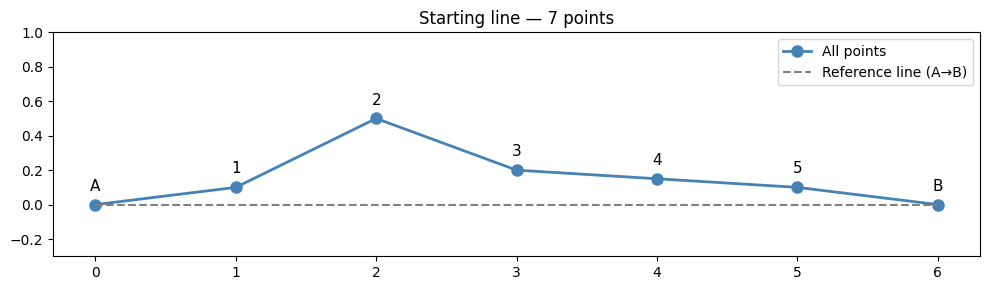

In [7]:
import sys
import matplotlib.pyplot as plt

print(sys.executable)

# A simple line with 7 points
points = [
    (0, 0),    # A — start
    (1, 0.1),  # 1
    (2, 0.5),  # 2  <- real bend
    (3, 0.2),  # 3
    (4, 0.15), # 4
    (5, 0.1),  # 5
    (6, 0),    # B — end
]

xs = [p[0] for p in points]
ys = [p[1] for p in points]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(xs, ys, 'o-', color='steelblue', linewidth=2, markersize=8, label='All points')
ax.plot([xs[0], xs[-1]], [ys[0], ys[-1]], '--', color='gray', linewidth=1.5, label='Reference line (A→B)')

for i, (x, y) in enumerate(points):
    label = ['A', '1', '2', '3', '4', '5', 'B'][i]
    ax.annotate(label, (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=11)

ax.legend()
ax.set_title('Starting line — 7 points')
ax.set_ylim(-0.3, 1.0)
plt.tight_layout()
plt.show()


## Round 1 — Full line A to B

The reference line goes from A (0, 0) to B (6, 0). We measure perpendicular distance from each interior point to that line.

Since the reference line lies along y = 0, the perpendicular distance is simply the y-coordinate of each point.

In [8]:
interior = points[1:-1]

print("Point  |  y (distance from reference line A→B)")
print("-" * 45)
for i, (x, y) in enumerate(interior, start=1):
    marker = "  <- maximum" if y == max(p[1] for p in interior) else ""
    print(f"  {i}    |  {y}{marker}")

Point  |  y (distance from reference line A→B)
---------------------------------------------
  1    |  0.1
  2    |  0.5  <- maximum
  3    |  0.2
  4    |  0.15
  5    |  0.1


Point 2 has the maximum distance (0.5). If epsilon is 0.3, then 0.5 > 0.3 — so **point 2 is kept**.

The line splits into two sub-problems: A→2 and 2→B.

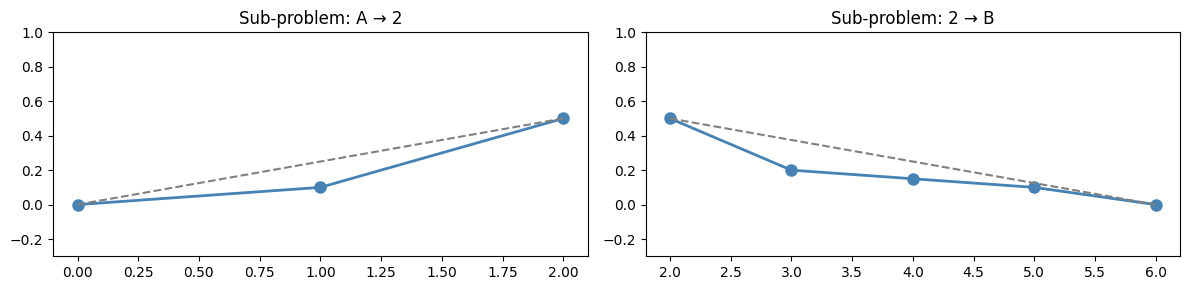

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

for ax, segment, title in [
    (axes[0], points[:3], 'Sub-problem: A → 2'),
    (axes[1], points[2:], 'Sub-problem: 2 → B'),
]:
    xs_ = [p[0] for p in segment]
    ys_ = [p[1] for p in segment]
    ax.plot(xs_, ys_, 'o-', color='steelblue', linewidth=2, markersize=8)
    ax.plot([xs_[0], xs_[-1]], [ys_[0], ys_[-1]], '--', color='gray', linewidth=1.5)
    ax.set_title(title)
    ax.set_ylim(-0.3, 1.0)

plt.tight_layout()
plt.show()

## Round 2 — Sub-problems

**Left sub-problem (A → 2):** only one interior point (point 1 at y=0.1). Its distance from the line A→2 is small. With epsilon=0.3, it is below threshold — **point 1 is discarded**.

**Right sub-problem (2 → B):** three interior points (3, 4, 5 at y=0.2, 0.15, 0.1). The reference line now goes from point 2 (2, 0.5) to B (6, 0). We measure distance from each interior point to *that* new reference line.

With epsilon=0.3 and the distances all falling below threshold, **points 3, 4, and 5 are all discarded**.

**Result:** we keep A, 2, and B — three points instead of seven.

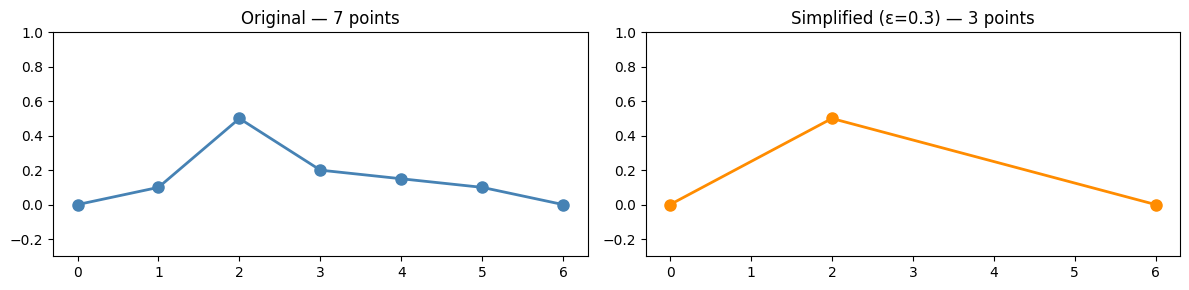

In [10]:
kept = [points[0], points[2], points[-1]]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Original
axes[0].plot(xs, ys, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title(f'Original — {len(points)} points')
axes[0].set_ylim(-0.3, 1.0)

# Simplified
kxs = [p[0] for p in kept]
kys = [p[1] for p in kept]
axes[1].plot(kxs, kys, 'o-', color='darkorange', linewidth=2, markersize=8)
axes[1].set_title(f'Simplified (ε=0.3) — {len(kept)} points')
axes[1].set_ylim(-0.3, 1.0)

plt.tight_layout()
plt.show()

## What Epsilon Controls

Epsilon is the only parameter. It is the maximum deviation you are willing to accept.

- **Small epsilon** → strict tolerance → more points kept → larger output, higher fidelity
- **Large epsilon** → loose tolerance → fewer points kept → smaller output, coarser shape

There is no universally correct epsilon. The right value depends on:
- the coordinate units (degrees vs. meters vs. pixels)
- the zoom level you are targeting
- how much visual distortion is acceptable

For geographic data in degrees, useful starting values are roughly:

| Epsilon | Visual effect |
|---------|---------------|
| 1.0     | Very coarse — major bends only |
| 0.1     | Continental scale — moderate |
| 0.01    | Regional scale — good detail |
| 0.001   | Local scale — nearly original |

## Exercise A

Consider this 5-point line:

```
A = (0, 0)
1 = (1, 0.05)
2 = (2, 0.8)
3 = (3, 0.04)
B = (4, 0)
```

Trace through the algorithm **by hand** (or in a comment) with `epsilon = 0.1`.

Which points are kept? Which are discarded? Show your reasoning for each step.

In [ ]:
# Trace through Douglas-Peucker on the 5-point line with epsilon=0.1
# Write your reasoning as comments, then plot the original and simplified result

five_points = [(0, 0), (1, 0.05), (2, 0.8), (3, 0.04), (4, 0)]
kept_eps_01 = five_points[:]  # every interior point survives at epsilon=0.1

print('Round 1: point (2, 0.8) is farthest from A->B, so it is kept.')
print('Left subproblem A->(2,0.8): point (1,0.05) is still farther than 0.1, so it is kept.')
print('Right subproblem (2,0.8)->B: point (3,0.04) is also farther than 0.1, so it is kept.')
print('Result: all 5 points remain.')

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
xs = [p[0] for p in five_points]
ys = [p[1] for p in five_points]
axes[0].plot(xs, ys, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Original 5-point line')
axes[0].set_ylim(-0.2, 1.0)

xs_s = [p[0] for p in kept_eps_01]
ys_s = [p[1] for p in kept_eps_01]
axes[1].plot(xs_s, ys_s, 'o-', color='darkorange', linewidth=2)
axes[1].set_title('Simplified with ε=0.1 (5 points kept)')
axes[1].set_ylim(-0.2, 1.0)
plt.tight_layout()
plt.show()

## Exercise B

Using the same 5-point line from Exercise A, trace the algorithm again with `epsilon = 1.0`.

How does the output change? What does this tell you about the relationship between epsilon and output size?

In [ ]:
five_points = [(0, 0), (1, 0.05), (2, 0.8), (3, 0.04), (4, 0)]
kept_eps_10 = [five_points[0], five_points[-1]]

print('At epsilon = 1.0, the maximum deviation (0.8) is below the tolerance.')
print('So the algorithm discards every interior point and keeps only the endpoints A and B.')
print('Larger epsilon means more aggressive simplification and a smaller output line.')

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
xs = [p[0] for p in five_points]
ys = [p[1] for p in five_points]
axes[0].plot(xs, ys, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Original 5-point line')
axes[0].set_ylim(-0.2, 1.0)

xs_s = [p[0] for p in kept_eps_10]
ys_s = [p[1] for p in kept_eps_10]
axes[1].plot(xs_s, ys_s, 'o-', color='darkorange', linewidth=2)
axes[1].set_title('Simplified with ε=1.0 (2 points kept)')
axes[1].set_ylim(-0.2, 1.0)
plt.tight_layout()
plt.show()

## Check Your Understanding

Douglas-Peucker always keeps the **first and last point** of any line segment — they are never candidates for removal.

Why is this necessary for the algorithm to work correctly? What would go wrong if endpoints could be discarded?

The endpoints define the reference segment that all interior distances are measured against, so removing them would change the problem itself at every recursive step. If endpoints could disappear, the simplified line might no longer start and end in the correct places, which would break connectivity and distort the feature's overall shape.

## Next

In [01 — Implementation](./01-Implementation.ipynb), we write the algorithm in Python and verify it against Shapely.